<a href="https://colab.research.google.com/github/MidhulaMS/EV-Population-Prediction/blob/Meenakshi.Model_building_KNN/EV_Population_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Libraries

In [54]:
#from google.colab import drive
#drive.mount('/content/drive')

In [55]:
from google.colab import drive
drive.mount('/content/drive')

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split

# Cross - validation, hyperparameter tuning (k-fold,grid)
from sklearn.model_selection import KFold, cross_val_score, GridSearchCV, RandomizedSearchCV

# Logistic Regression
from sklearn.linear_model import LogisticRegression
# k-NN
from sklearn.neighbors import KNeighborsClassifier
# Decision Tree
from sklearn.tree import DecisionTreeClassifier
# Random Forest
from sklearn.ensemble import RandomForestClassifier


# Bagging
from sklearn.ensemble import BaggingClassifier
# Naive Bayes
from sklearn.naive_bayes import GaussianNB
# Boosting
from sklearn.ensemble import AdaBoostClassifier



# Evaluation metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# For evaluating Mode
from statistics import mode

# For min max scaling
from sklearn.preprocessing import MinMaxScaler

# Reading Data

In [57]:
filepath =  "/content/drive/MyDrive/DATA/export (1).csv"

In [58]:
EV_df = pd.read_csv(filepath)

# Exploratory data analysis (EDA)


In [59]:
EV_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 289564 entries, 0 to 289563
Data columns (total 16 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         289564 non-null  object 
 1   County                                             289555 non-null  object 
 2   City                                               289555 non-null  object 
 3   State                                              289564 non-null  object 
 4   Postal Code                                        289555 non-null  float64
 5   Model Year                                         289564 non-null  int64  
 6   Make                                               289564 non-null  object 
 7   Model                                              289564 non-null  object 
 8   Electric Vehicle Type                              289564 non-null  object

In [60]:
EV_df.head()

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,5UX43EU07S,Snohomish,Snohomish,WA,98296.0,2025,BMW,X5,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,40.0,44.0,279314360,POINT (-122.1389 47.87115),PUGET SOUND ENERGY INC,5.306105e+10
1,5YJ3E1EB5J,Yakima,Yakima,WA,98901.0,2018,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,215.0,14.0,220635992,POINT (-120.50729 46.60464),PACIFICORP,5.307700e+10
2,WA1AAAGE5M,King,Seattle,WA,98112.0,2021,AUDI,E-TRON,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,222.0,43.0,282112967,POINT (-122.30207 47.64085),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
3,5YJXCAE2XG,Kitsap,Bremerton,WA,98310.0,2016,TESLA,MODEL X,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,200.0,23.0,103165100,POINT (-122.61136 47.5752),PUGET SOUND ENERGY INC,5.303508e+10
4,5YJ3E1EB5J,Yakima,Yakima,WA,98908.0,2018,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,215.0,14.0,301024209,POINT (-120.60272 46.59656),PACIFICORP,5.307700e+10


In [61]:
# Numerical Data - Electric Range
# Categorical Data - County,City,State,postal code,Make,Model,ElectricVehicleType,Model Year,CAFV,Eligibility,Electric Utility,Legislative District,Vehicle Location,Electric Utility,2020 Census Tract
# Identifiers- VIN,DOL Vehicle ID

In [62]:
EV_df.shape

(289564, 16)

In [63]:
EV_df.describe()

,Postal Code,Model Year,Electric Range,Legislative District,DOL Vehicle ID,2020 Census Tract
count,289555.000000,289564.000000,289554.000000,288837.000000,2.895640e+05,2.895550e+05
mean,98179.343375,2022.255957,37.399770,28.800787,2.495999e+08,5.297009e+10
std,2595.465980,3.080426,76.741728,14.888276,6.267330e+07,1.656928e+09
min,1030.000000,1999.000000,0.000000,1.000000,4.385000e+03,1.001020e+09
25%,98052.000000,2021.000000,0.000000,17.000000,2.271862e+08,5.303301e+10
50%,98133.000000,2023.000000,0.000000,32.000000,2.670574e+08,5.303303e+10
75%,98388.000000,2024.000000,32.000000,42.000000,2.827402e+08,5.305394e+10
max,99801.000000,2027.000000,337.000000,49.000000,4.791150e+08,6.601095e+10


In [64]:
# Electric Range minimum value is "0" which needs to be inspected.

In [65]:
EV_df.columns

Index(['VIN (1-10)', 'County', 'City', 'State', 'Postal Code', 'Model Year',
       'Make', 'Model', 'Electric Vehicle Type',
       'Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Electric Range',
       'Legislative District', 'DOL Vehicle ID', 'Vehicle Location',
       'Electric Utility', '2020 Census Tract'],
      dtype='object')

### finding missing values

In [66]:
EV_df.isna().sum()

,0
VIN (1-10),0
County,9
City,9
State,0
Postal Code,9
Model Year,0
Make,0
Model,0
Electric Vehicle Type,0
Clean Alternative Fuel Vehicle (CAFV) Eligibility,0


In [67]:
EV_df.duplicated().sum()

np.int64(0)

In [68]:
EV_df['Electric Vehicle Type'].unique()

array(['Plug-in Hybrid Electric Vehicle (PHEV)',
       'Battery Electric Vehicle (BEV)'], dtype=object)

In [69]:
EV_df.nunique()

,0
VIN (1-10),17883
County,249
City,920
State,53
Postal Code,1157
Model Year,23
Make,49
Model,198
Electric Vehicle Type,2
Clean Alternative Fuel Vehicle (CAFV) Eligibility,3


In [70]:
EV_df["Electric Vehicle Type"].value_counts(dropna=False)

,count
Electric Vehicle Type,
Battery Electric Vehicle (BEV),233544
Plug-in Hybrid Electric Vehicle (PHEV),56020


In [71]:
EV_df.duplicated().sum()

np.int64(0)

In [72]:
EV_df["Electric Vehicle Type"].isnull().sum()

np.int64(0)

## Visual EDA(Plotting)

### Univariate analysis

In [73]:
numerical_features = [
    "Electric Range"
]

categorical_features = [
    "County",
    "City",
    "State",
    "Postal Code",
    "Model Year",
    "Make",
    "Model",
    "Electric Vehicle Type",
    "Clean Alternative Fuel Vehicle (CAFV) Eligibility",
    "Legislative District",
    "Electric Utility",
    "Vehicle Location",
    "2020 Census Tract"
]

identifier_features = [
    "VIN (1-10)",
    "DOL Vehicle ID"
]

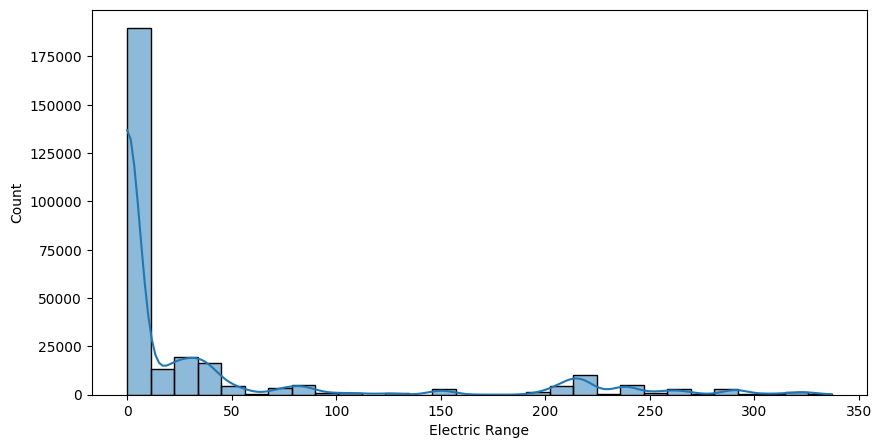

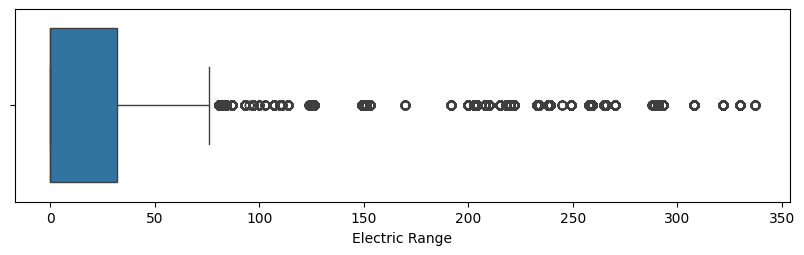

In [74]:
plt.figure(figsize=(10,5))
sns.histplot(EV_df["Electric Range"], kde=True, bins=30)
plt.show()

plt.figure(figsize=(10,2.5))
sns.boxplot(x=EV_df["Electric Range"])
plt.show()

In [75]:
# Data is right skewed since the right whiskers is longer.
# Electric Range contains several high-value outliers.But high range vehicles need to be investigated before treating them as outliers.

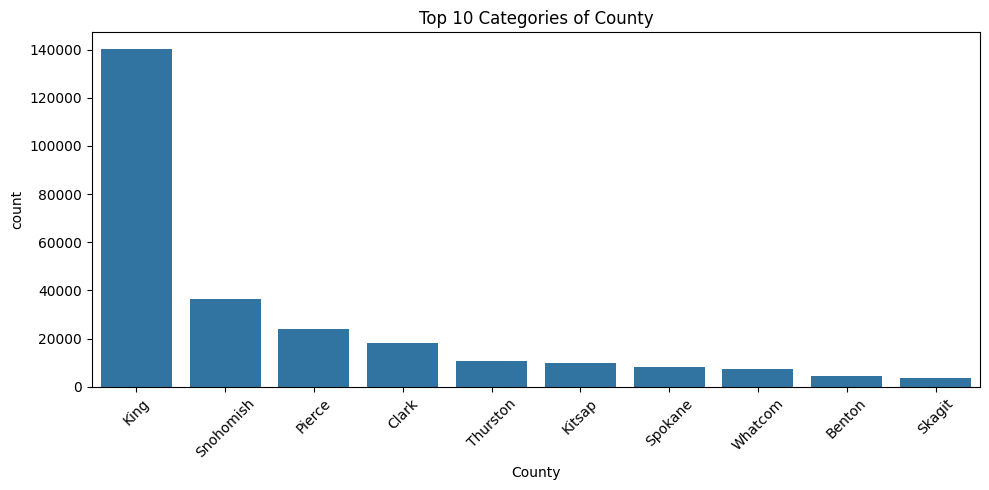

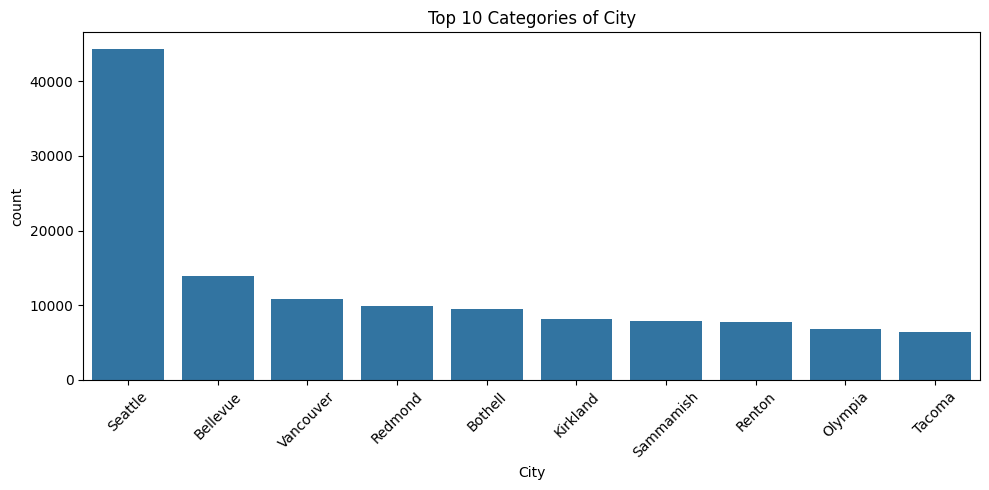

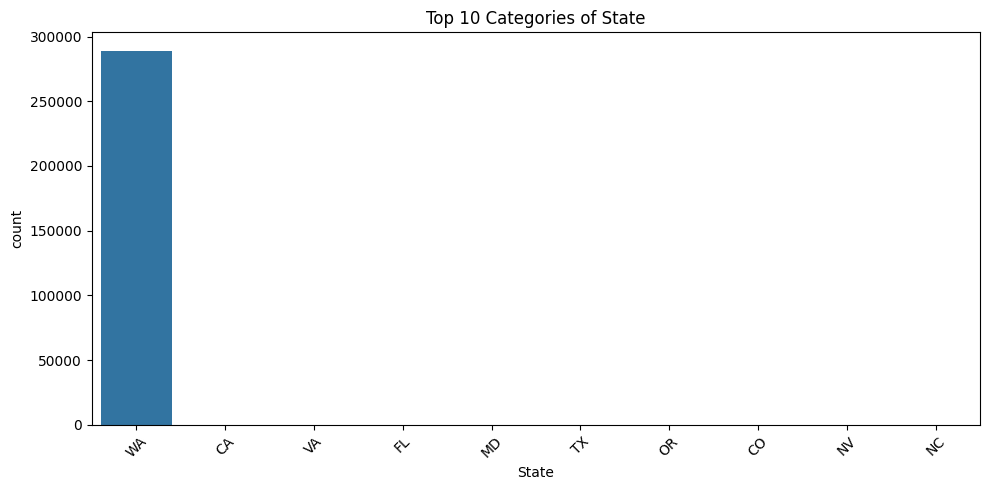

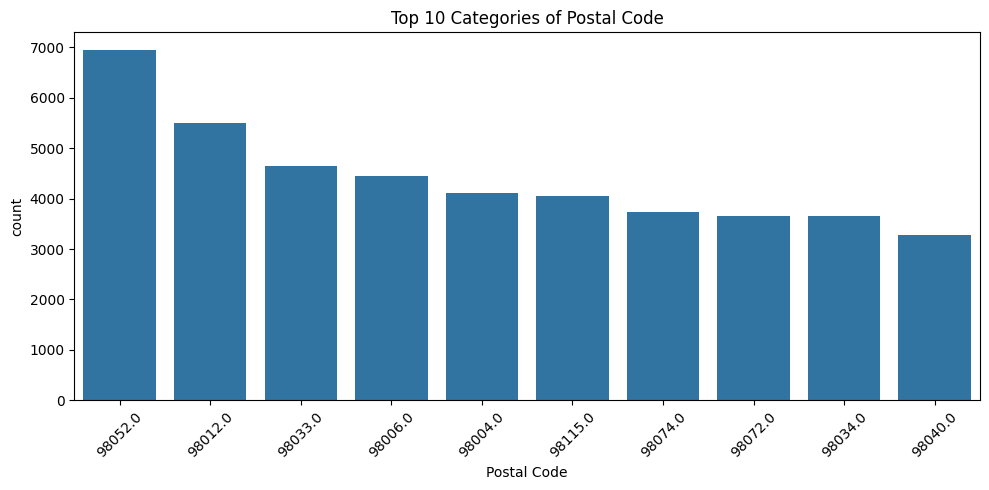

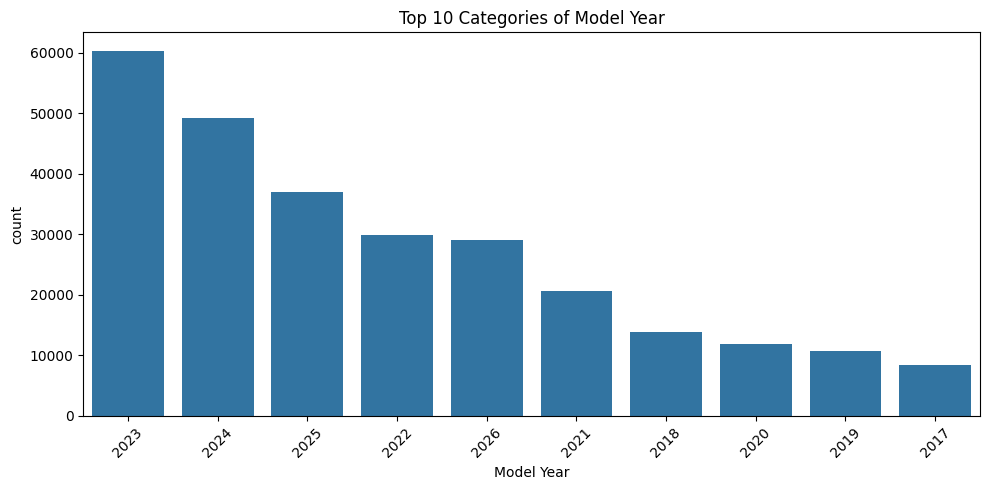

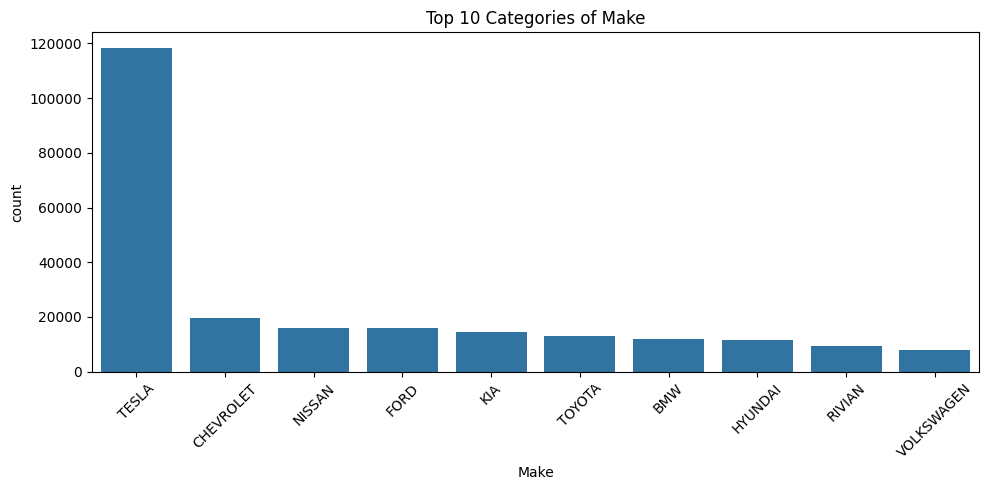

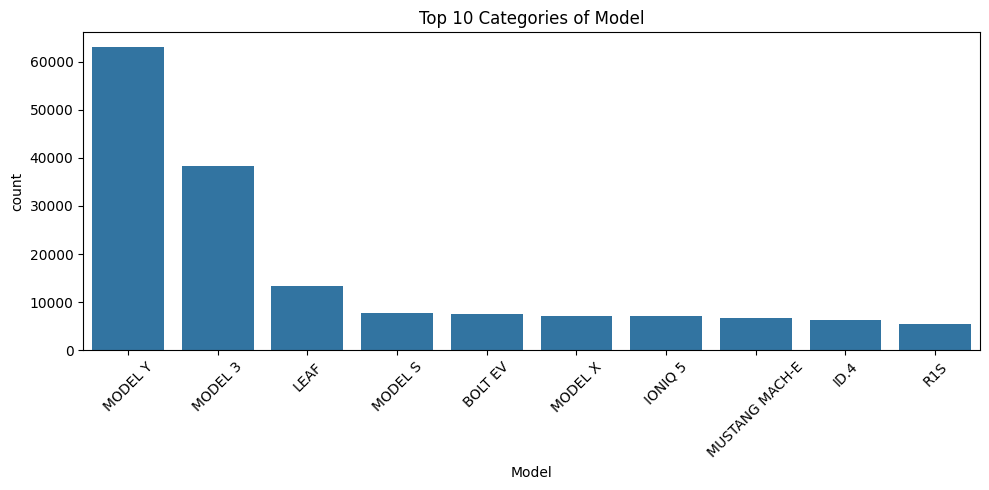

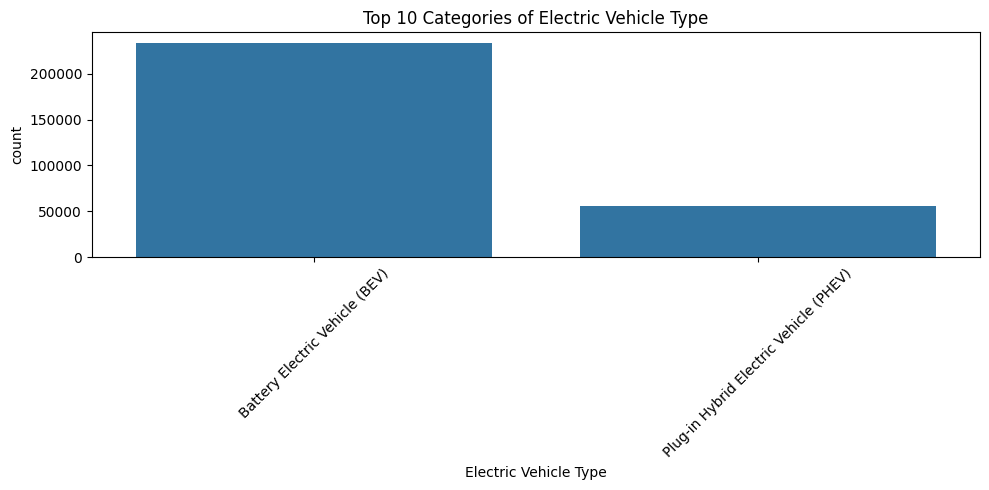

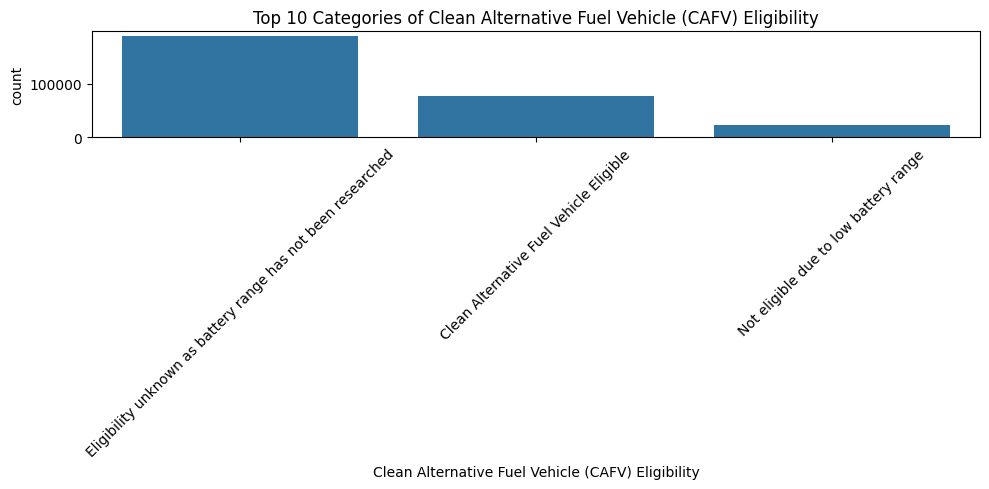

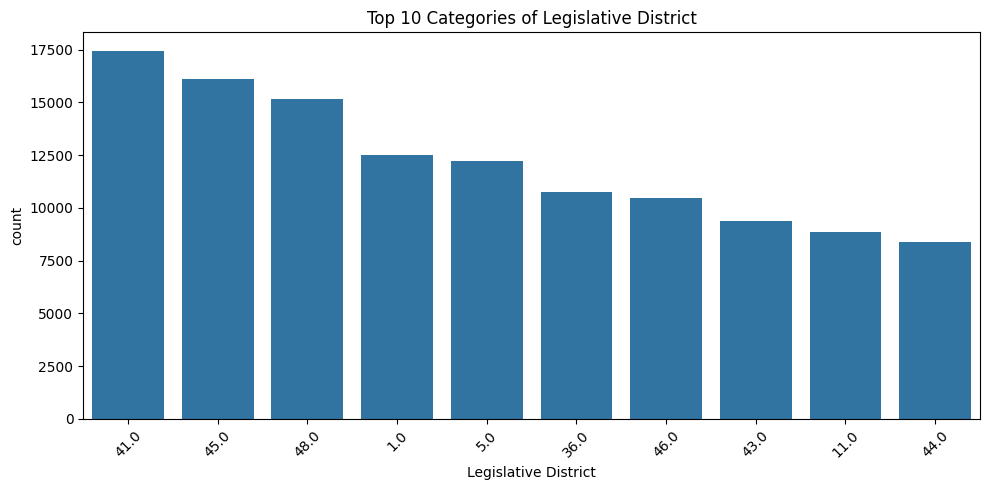

/tmp/ipykernel_10555/2614859388.py:16: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


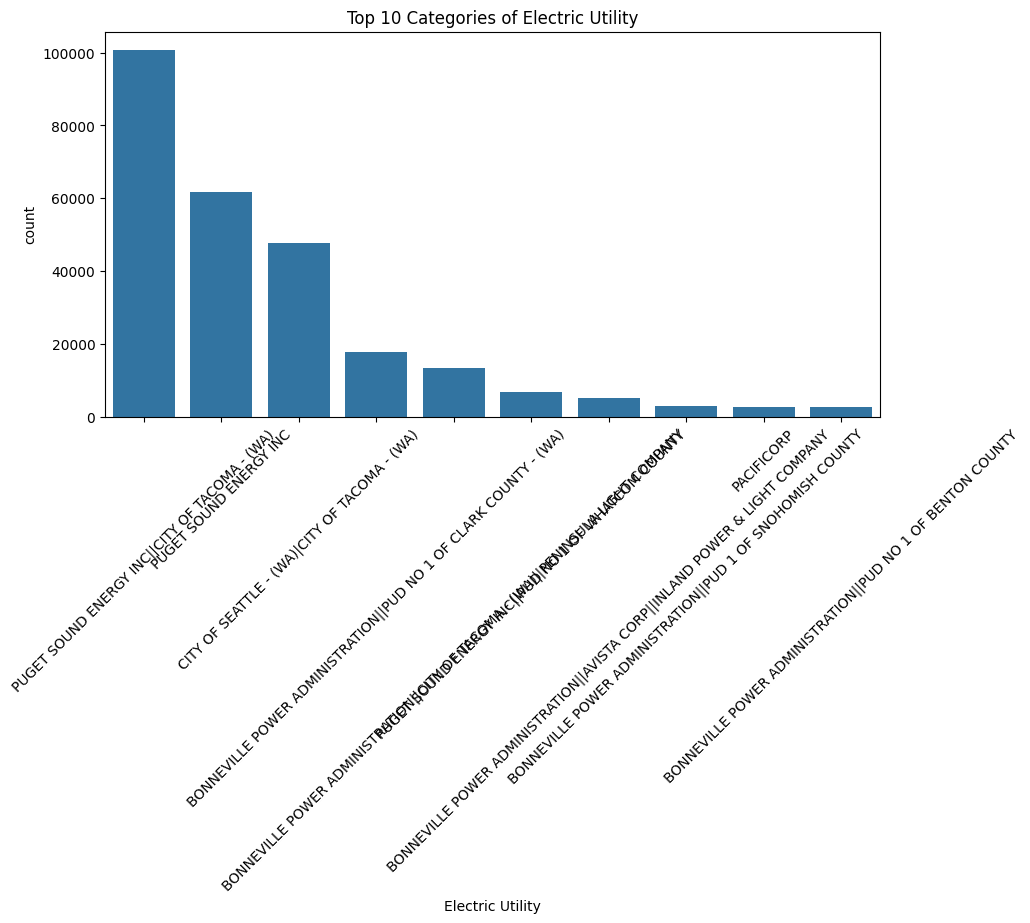

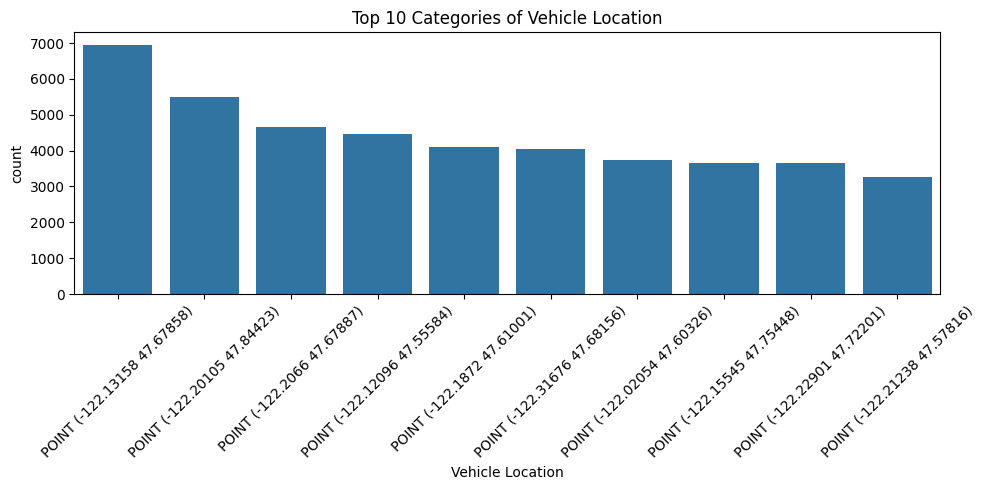

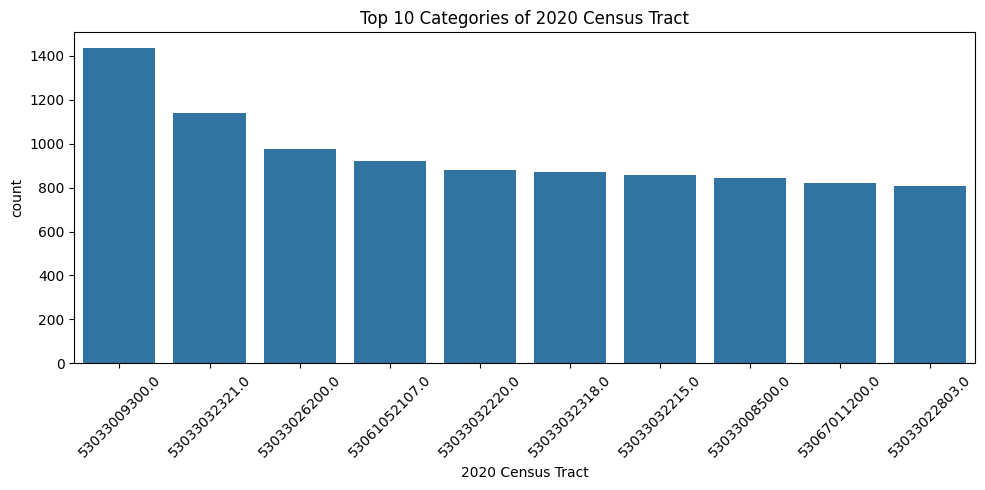

In [76]:
for col in categorical_features:

    plt.figure(figsize=(10,5))

    top10 = EV_df[col].value_counts().head(10).index

    sns.countplot(
        data=EV_df,
        x=col,
        order=top10
    )

    plt.title(f"Top 10 Categories of {col}")
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

In [77]:
# From observing Categorical data we understands:
#In 'States' only one state exists this feature has no variation.

### Bivariate Analysis

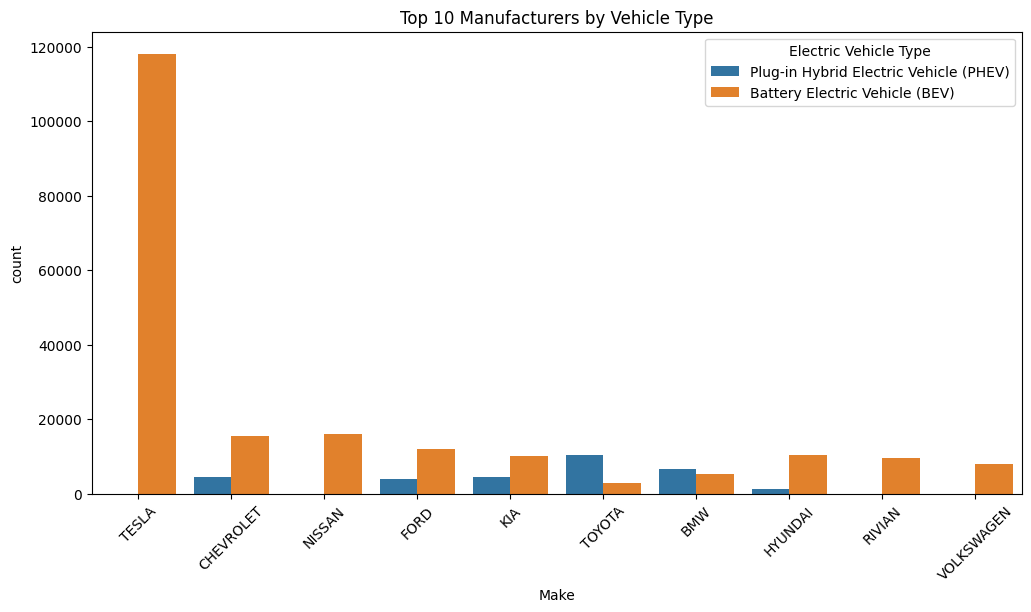

In [78]:
plt.figure(figsize=(12,6))

top10 = EV_df["Make"].value_counts().head(10).index

sns.countplot(
    data=EV_df[EV_df["Make"].isin(top10)],
    x="Make",
    hue="Electric Vehicle Type",
    order=top10
)

plt.xticks(rotation=45)
plt.title("Top 10 Manufacturers by Vehicle Type")
plt.show()

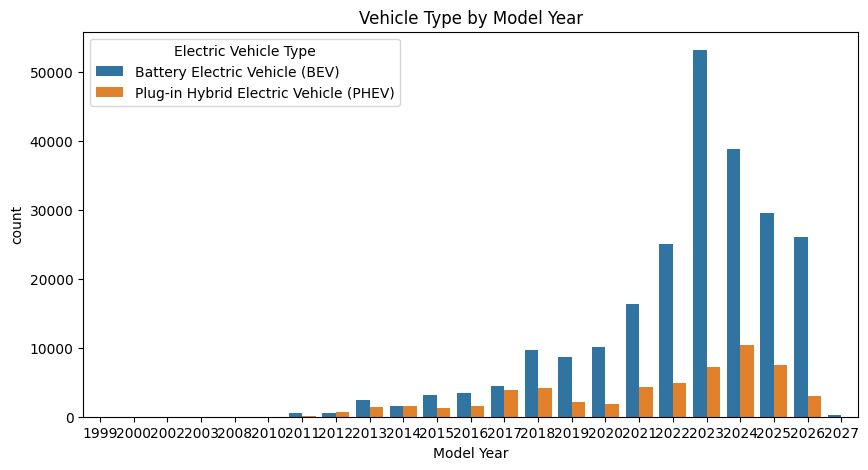

In [79]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=EV_df,
    x="Model Year",
    hue="Electric Vehicle Type"
)

plt.title("Vehicle Type by Model Year")
plt.show()

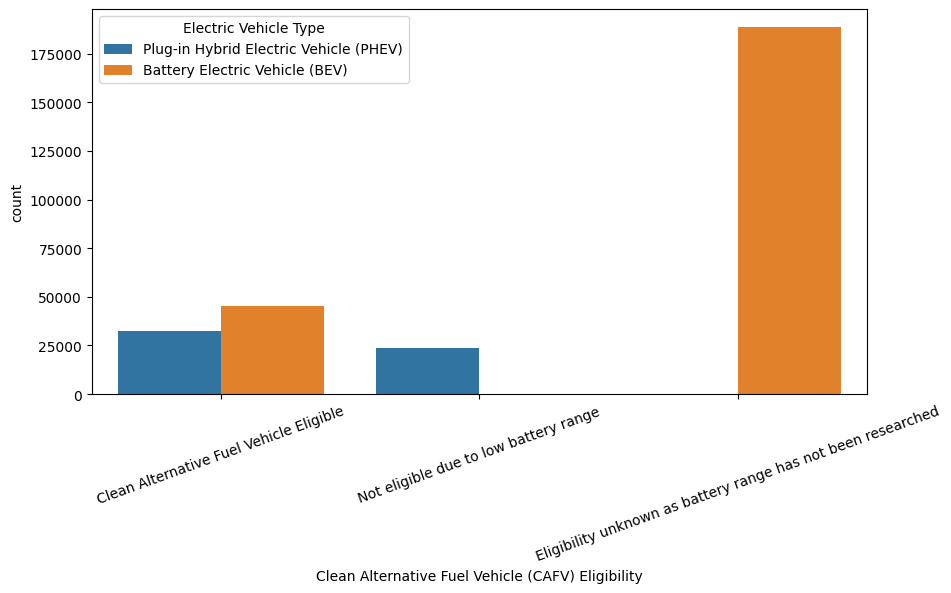

In [80]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=EV_df,
    x="Clean Alternative Fuel Vehicle (CAFV) Eligibility",
    hue="Electric Vehicle Type"
)

plt.xticks(rotation=20)
plt.show()

In [81]:
#Model Year is strongly associated with Electric Vehicle Type and should be retained as a predictive feature.

### correlaton heatmap

In [82]:
#A correlation heatmap was not generated because the dataset contains only one continuous numerical feature

# Data preprocessing

## Data Cleaning

In [83]:
# Removing (VIN (1-10), DOL Vehicle ID)-Identifiers no importance in prediction.
# State - Unique Value repeated.
# Vehicle Location - Too many unique values
# 2020 Census tract,Postal code - Behaves like a identifier

In [84]:
drop_cols = [
    "VIN (1-10)",
    "DOL Vehicle ID",
    "State",
    "Vehicle Location","Postal Code",
    "2020 Census Tract"
]

EV_df = EV_df.drop(columns=drop_cols)

### Missing Value Handling

In [85]:
EV_df.isnull().sum()  #Check missing values

,0
County,9
City,9
Model Year,0
Make,0
Model,0
Electric Vehicle Type,0
Clean Alternative Fuel Vehicle (CAFV) Eligibility,0
Electric Range,10
Legislative District,727
Electric Utility,9


In [86]:
missing = EV_df.isnull().sum()

missing_percentage = (missing / len(EV_df)) * 100

pd.DataFrame({
    "Missing Values": missing,
    "Percentage": missing_percentage
}).sort_values("Missing Values", ascending=False)

,Missing Values,Percentage
Legislative District,727,0.251067
Electric Range,10,0.003453
City,9,0.003108
County,9,0.003108
Electric Utility,9,0.003108
Model Year,0,0.000000
Electric Vehicle Type,0,0.000000
Model,0,0.000000
Make,0,0.000000
Clean Alternative Fuel Vehicle (CAFV) Eligibility,0,0.000000


In [87]:
# Fill categorical columns with mode
cat_fill = [
    "County",
    "City",
    "Electric Utility",
    "Legislative District"
]

for col in cat_fill:
    EV_df[col].fillna(EV_df[col].mode()[0], inplace=True)
EV_df.isnull().sum()



/tmp/ipykernel_10555/876020920.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  EV_df[col].fillna(EV_df[col].mode()[0], inplace=True)


,0
County,0
City,0
Model Year,0
Make,0
Model,0
Electric Vehicle Type,0
Clean Alternative Fuel Vehicle (CAFV) Eligibility,0
Electric Range,10
Legislative District,0
Electric Utility,0


In [88]:
for col in cat_fill:
    EV_df[col].fillna(EV_df[col].mode()[0], inplace=True)

# Fill numerical column with median
EV_df["Electric Range"].fillna(
    EV_df["Electric Range"].median(),
    inplace=True
)
EV_df.isnull().sum()

/tmp/ipykernel_10555/4250564942.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  EV_df[col].fillna(EV_df[col].mode()[0], inplace=True)
/tmp/ipykernel_10555/4250564942.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)

,0
County,0
City,0
Model Year,0
Make,0
Model,0
Electric Vehicle Type,0
Clean Alternative Fuel Vehicle (CAFV) Eligibility,0
Electric Range,0
Legislative District,0
Electric Utility,0


### Handling Duplicates

In [89]:
duplicate_rows = EV_df.duplicated().sum()

print(f"Duplicate Rows: {duplicate_rows}")

Duplicate Rows: 218705


In [90]:
EV_df = EV_df.drop_duplicates()
# Removed all duplicate columns

## Outlier Handling

In [91]:
# Using the IQR method
Q1 = EV_df['Electric Range'].quantile(0.25)
Q3 = EV_df['Electric Range'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Lower bound: {lower_bound}, Upper bound: {upper_bound}")

Q1: 0.0, Q3: 38.0, IQR: 38.0
Lower bound: -57.0, Upper bound: 95.0


In [92]:
outliers = EV_df[
    (EV_df['Electric Range'] < lower_bound) |
    (EV_df['Electric Range'] > upper_bound)
]
print(f"Number of outliers: {len(outliers)}")

Number of outliers: 9106


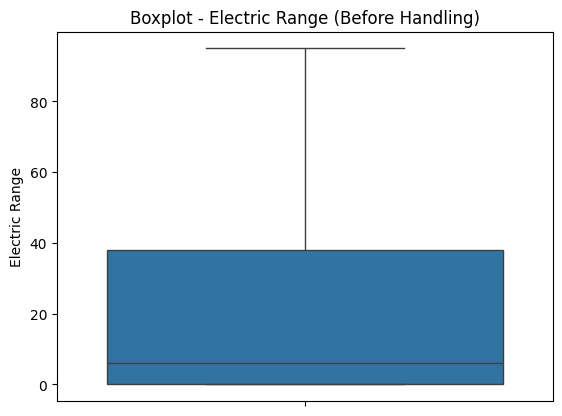

In [93]:
EV_df['Electric Range'] = EV_df['Electric Range'].clip(
    lower=lower_bound, upper=upper_bound)


# Checking whether the Outliers were clipped
sns.boxplot(EV_df['Electric Range'])
plt.title('Boxplot - Electric Range (Before Handling)')
plt.show()

# Data Transformation

## Scaling

In [94]:
# Numerical columns
num_cols = EV_df.select_dtypes(include = ['int64', 'float64']).columns
num_cols

Index(['Model Year', 'Electric Range', 'Legislative District'], dtype='object')

In [95]:
# Categorical Columns
cat_cols = EV_df.select_dtypes(include = ['object']).columns
cat_cols

Index(['County', 'City', 'Make', 'Model', 'Electric Vehicle Type',
       'Clean Alternative Fuel Vehicle (CAFV) Eligibility',
       'Electric Utility'],
      dtype='object')

### Min-Max Scaling : Scaling technique that transforms data into a fixed range, usually 0 to 1.

In [96]:
skewed_cols =['Model Year','Electric Range']

In [97]:
# Before min max scaling
EV_df.head(2)

,County,City,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,Electric Utility
0,Snohomish,Snohomish,2025,BMW,X5,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,40.0,44.0,PUGET SOUND ENERGY INC
1,Yakima,Yakima,2018,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,95.0,14.0,PACIFICORP


In [98]:
# object for min-max scaling
minmax_scaler = MinMaxScaler()
EV_df[skewed_cols] = minmax_scaler.fit_transform(EV_df[skewed_cols])

In [99]:
# After min max scaling
EV_df.head(2)

,County,City,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,Electric Utility
0,Snohomish,Snohomish,0.928571,BMW,X5,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,0.421053,44.0,PUGET SOUND ENERGY INC
1,Yakima,Yakima,0.678571,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,1.000000,14.0,PACIFICORP


## Encoding

In [100]:
# Categorical Columns
cat_cols = EV_df.select_dtypes(include = ['object']).columns
cat_cols

Index(['County', 'City', 'Make', 'Model', 'Electric Vehicle Type',
       'Clean Alternative Fuel Vehicle (CAFV) Eligibility',
       'Electric Utility'],
      dtype='object')

In [101]:
from sklearn.preprocessing import LabelEncoder
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    EV_df[col] = le.fit_transform(EV_df[col].astype(str))
    label_encoders[col] = le
EV_df.head()

,County,City,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,Electric Utility
0,207,762,0.928571,6,191,1,0,0.421053,44.0,74
1,243,913,0.678571,42,112,0,0,1.000000,14.0,66
2,114,739,0.785714,3,50,0,0,1.000000,43.0,58
3,116,87,0.607143,42,114,0,0,1.000000,23.0,74
5,243,913,0.750000,42,115,0,0,1.000000,14.0,66


# Model Building

## Data Splitting


In [102]:
y = EV_df['Electric Vehicle Type']
X = EV_df.drop(columns = ['Electric Vehicle Type'], axis = 1)

# split into train-test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state =33)


##Model Building Using KNN

In [103]:
#build the model obj
kNN = KNeighborsClassifier(n_neighbors=4)
#train the model
kNN.fit(X_train,y_train)
#make prediction using the ,model
y_pred_kNN = kNN.predict(X_test)
#evaluate the model performance
acc_kNN = accuracy_score(y_test,y_pred_kNN)
print('Accuracy comparison')
print('**********')
print('Accuracy of KNN model:',acc_kNN)

Accuracy comparison
**********
Accuracy of KNN model: 0.8618402483770816


##Cross Validation for Model Building

###K-Fold cross validation

In [104]:
kf_obj = KFold(n_splits=5,shuffle=True,random_state=29)

scores = cross_val_score(kNN, X_train, y_train, cv=5, scoring='accuracy')
print('Cross-validation scores:', scores)
print('Mean CV accuracy:', np.mean(scores))

Cross-validation scores: [0.84565179 0.84335862 0.84757872 0.83902267 0.84113963]
Mean CV accuracy: 0.8433502864883572


###Grid search Cross validation

In [105]:
# --- Cross validation to find best k ---
param_grid = {'n_neighbors': list(range(1, 21))}

grid_search = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid_search.fit(X_train, y_train)

print('Best k:', grid_search.best_params_)
print('Best CV accuracy:', grid_search.best_score_)

# Use the best model found
best_kNN = grid_search.best_estimator_
y_pred_kNN = best_kNN.predict(X_test)

acc_kNN = accuracy_score(y_test, y_pred_kNN)
print('Accuracy of best KNN model:', acc_kNN)

Best k: {'n_neighbors': 1}
Best CV accuracy: 0.9048282268716369
Accuracy of best KNN model: 0.9235817104149027


###RandomizedSearchCV


In [106]:
# Define the parameters to check
para_grid = {
    'n_neighbors': list(range(1, 21)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

# Build the model object
random_search = RandomizedSearchCV(KNeighborsClassifier(),
    param_distributions=para_grid,
    n_iter=10,
    cv=5,
    scoring='accuracy',
    random_state=42
)

# Train the model
random_search.fit(X_train, y_train)

# Display the best parameters and score
print('Best parameters are:', random_search.best_params_)
print('Best cross validation score is:', random_search.best_score_)

# Build the model using the best parameters
kNN_model_HPT = random_search.best_estimator_

# Make predictions using the model
y_pred_kNN_HPT = kNN_model_HPT.predict(X_test)

# Evaluate the model performance
acc_kNN_HPT = accuracy_score(y_test, y_pred_kNN_HPT)

print('Accuracy:', acc_kNN_HPT)

Best parameters are: {'weights': 'distance', 'n_neighbors': 8, 'metric': 'manhattan'}
Best cross validation score is: 0.9147952356152775
Accuracy: 0.9295794524414338


###Bagging

In [107]:
# build the model object
bM_model = BaggingClassifier(KNeighborsClassifier())
#train the model
bM_model.fit(X_train, y_train)
# make predictions using the model
y_pred_bM = bM_model.predict(X_test)
#evaluate the model performance
acc_BM =accuracy_score(y_test,y_pred_bM)
print("Accuracy of Bagging Model:",acc_BM)

Accuracy of Bagging Model: 0.8584532881738639
